<a href="https://colab.research.google.com/github/nhuwynh07/THDeepLearning/blob/main/DL_Tuan02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/refs/heads/main/Data/04_CIGARET.csv"

df = pd.read_csv(url)

print(df.head())

   KgTar  KgNic  KgCO  MnTar  MnNic  MnCO  FLTar  FLNic  FLCO
0     20    1.1    16     16    1.1    15      5    0.4     4
1     27    1.7    16     13    0.8    17     16    1.0    19
2     27    1.7    16     16    1.0    19     17    1.2    17
3     20    1.1    16      9    0.9     9     13    0.8    18
4     20    1.1    16     14    0.8    17     13    0.8    18


In [ ]:
print(df.shape)

(25, 9)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KgTar   25 non-null     int64  
 1   KgNic   25 non-null     float64
 2   KgCO    25 non-null     int64  
 3   MnTar   25 non-null     int64  
 4   MnNic   25 non-null     float64
 5   MnCO    25 non-null     int64  
 6   FLTar   25 non-null     int64  
 7   FLNic   25 non-null     float64
 8   FLCO    25 non-null     int64  
dtypes: float64(3), int64(6)
memory usage: 1.9 KB
None


In [ ]:
print(df.isnull().sum())

KgTar    0
KgNic    0
KgCO     0
MnTar    0
MnNic    0
MnCO     0
FLTar    0
FLNic    0
FLCO     0
dtype: int64


In [ ]:
df = df.dropna()

Phát hiện outlier

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outlier = ((df < (Q1 - 1.5 * IQR)) |
           (df > (Q3 + 1.5 * IQR)))

print(outlier.sum())


KgTar    1
KgNic    0
KgCO     8
MnTar    6
MnNic    3
MnCO     6
FLTar    4
FLNic    1
FLCO     3
dtype: int64


Xử lý Outlier

In [ ]:
df_clean = df[~((df < (Q1 - 1.5 * IQR)) |
                (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features & target
X = df_clean[['KgTar', 'KgNic']]
y = df_clean['KgCO']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.0
MSE: 0.0
R2: 1.0


Epoch 001 | Train Loss: 256.1302 | Test Loss: 235.3319
Epoch 002 | Train Loss: 245.9827 | Test Loss: 226.2197
Epoch 003 | Train Loss: 236.2373 | Test Loss: 217.4567
Epoch 004 | Train Loss: 226.8783 | Test Loss: 209.0296
Epoch 005 | Train Loss: 217.8902 | Test Loss: 200.9257
Epoch 006 | Train Loss: 209.2583 | Test Loss: 193.1329
Epoch 007 | Train Loss: 200.9685 | Test Loss: 185.6394
Epoch 008 | Train Loss: 193.0072 | Test Loss: 178.4339
Epoch 009 | Train Loss: 185.3615 | Test Loss: 171.5054
Epoch 010 | Train Loss: 178.0187 | Test Loss: 164.8435
Epoch 011 | Train Loss: 170.9669 | Test Loss: 158.4381
Epoch 012 | Train Loss: 164.1945 | Test Loss: 152.2794
Epoch 013 | Train Loss: 157.6905 | Test Loss: 146.3580
Epoch 014 | Train Loss: 151.4442 | Test Loss: 140.6650
Epoch 015 | Train Loss: 145.4454 | Test Loss: 135.1916
Epoch 016 | Train Loss: 139.6843 | Test Loss: 129.9295
Epoch 017 | Train Loss: 134.1515 | Test Loss: 124.8706
Epoch 018 | Train Loss: 128.8378 | Test Loss: 120.0071
Epoch 019 

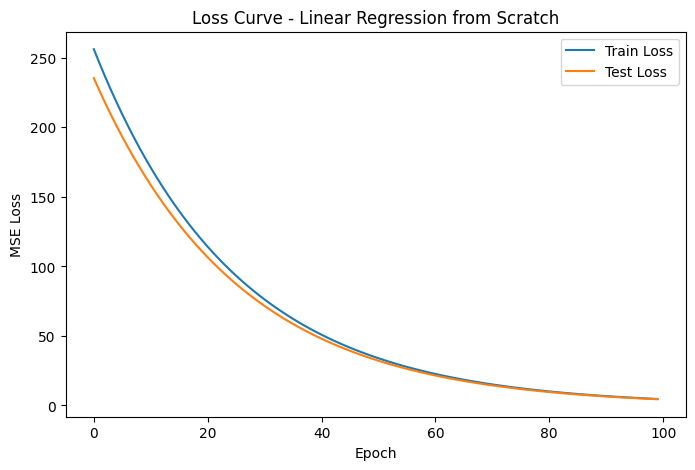

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# Chọn input và output
X = df_clean[['KgTar', 'KgNic']].values
y = df_clean['KgCO'].values.reshape(-1, 1)

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Chuẩn hóa input
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Khởi tạo tham số
np.random.seed(42)

n_samples, n_features = X_train.shape

W = np.random.randn(n_features, 1)
b = 0

learning_rate = 0.01
epochs = 100

# Early stopping
patience = 20
best_loss = float('inf')
counter = 0

# Save best model
best_W = None
best_b = None

train_losses = []
test_losses = []

# Train model
for epoch in range(epochs):

    # Forward: y_pred = XW + b
    y_train_pred = np.dot(X_train, W) + b

    # Loss MSE
    train_loss = np.mean((y_train_pred - y_train) ** 2)

    # Gradient
    dW = (2 / n_samples) * np.dot(X_train.T, (y_train_pred - y_train))
    db = (2 / n_samples) * np.sum(y_train_pred - y_train)

    # Update W, b
    W = W - learning_rate * dW
    b = b - learning_rate * db

    # Test loss
    y_test_pred = np.dot(X_test, W) + b
    test_loss = np.mean((y_test_pred - y_test) ** 2)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # In kết quả mỗi epoch
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

    # Early stopping check
    if test_loss < best_loss:

        best_loss = test_loss
        counter = 0

        best_W = W.copy()
        best_b = b

    else:
        counter += 1

    # Stop
    if counter >= patience:
        print("\nEarly Stopping Triggered!")
        print(f"Stopped at epoch {epoch+1}")

        break

# Restore best model
W = best_W
b = best_b

# Đánh giá cuối cùng
y_pred = np.dot(X_test, W) + b

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nKẾT QUẢ CUỐI CÙNG")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

print("\nTrọng số W:")
print(W)

print("\nBias b:")
print(b)

# Vẽ loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve - Linear Regression from Scratch")
plt.legend()
plt.show()